In [134]:
import random, os, pandas as pd, numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import GroverOperator
from qiskit.transpiler import CouplingMap
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler, fake_provider
from iqm.iqm_client import IQMClient
from iqm.qiskit_iqm import IQMBackend, IQMCircuit
from dotenv import load_dotenv


In [2]:
load_dotenv(dotenv_path="tokens.env")
token = os.getenv('IQM_TOKEN')

In [3]:
backendName = "garnet_mock"

In [4]:
IQMdict = {
    "garnet" : 'https://cocos.resonance.meetiqm.com/garnet',
    "garnet_mock" : 'https://cocos.resonance.meetiqm.com/garnet:mock', 
    "sirius" : 'https://cocos.resonance.meetiqm.com/sirius',
    "sirius_mock" : 'https://cocos.resonance.meetiqm.com/sirius:mock',
    "emerald": "https://cocos.resonance.meetiqm.com/emerald",
    "emerald_mock": "https://cocos.resonance.meetiqm.com/emerald:mock"
}

try:
    backendURL = IQMdict[backendName]
except KeyError:
    raise ValueError(f"Backend '{backendName}' does not exist in available QMAP backends dictionary")

try:
    os.environ.pop('IQM_TOKEN', None)
    backend = IQMBackend(IQMClient(backendURL, token=token))
    print(f"{' ':4}Successfully retrieved backend: {backendName}")
except Exception as e:
    raise RuntimeError(f"Failed to retrieve backend: {str(e)}")

try:
    sampler = Sampler(mode=backend)
    print(f"{' ':4}Successfully retrieved sampler!")
except Exception as e:
    raise RuntimeError(f"Failed to retrieve sampler: {str(e)}")

    Successfully retrieved backend: garnet_mock
    Successfully retrieved sampler!


In [5]:
def grovers(qubits):
    iterations = 1

    targetBitstring = ''.join(random.choice('01') for _ in range(qubits))

    n = len(targetBitstring)
    oracle = QuantumCircuit(n)

    # Step 1: Flip qubits where target bit is '0'
    for i, bit in enumerate(reversed(targetBitstring)):
        if bit == '0':
            oracle.x(i)

    # Step 2: Multi-controlled-Z gate (flip amplitude of target)
    oracle.h(n - 1)
    if n == 1:
        oracle.z(0)
    elif n == 2:
        oracle.cz(0, 1)
    else:
        oracle.mcx(list(range(n - 1)), n - 1)
    oracle.h(n - 1)

    # Step 3: Undo flips
    for i, bit in enumerate(reversed(targetBitstring)):
        if bit == '0':
            oracle.x(i)


    grover_op = GroverOperator(oracle)

    qc = QuantumCircuit(qubits, qubits)
    qc.h(range(qubits))  # Initial superposition

    for _ in range(iterations):
        qc.append(grover_op, range(qubits))

    qc.measure(range(qubits), range(qubits))

    return qc



In [6]:
circ = grovers(4)

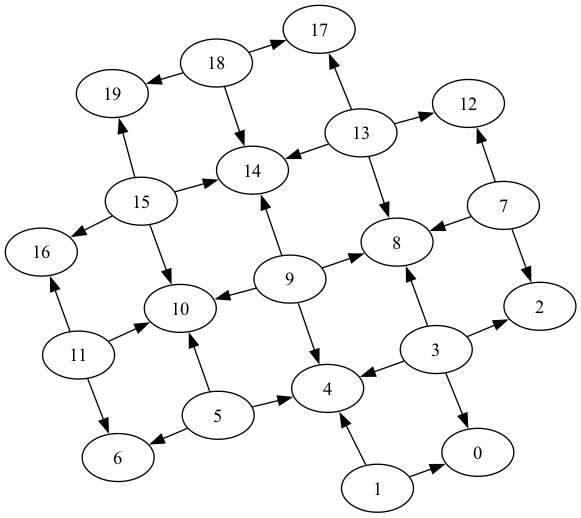

In [7]:
backend._coupling_map.draw()

In [147]:
tc = transpile(circ, backend, optimization_level=3)
dict(tc.count_ops())

{'r': 57, 'cz': 35, 'measure': 4}

In [148]:
# tc = transpile(circ, backend, optimization_level=3)

valid_cz_pairs = list(backend.target['cz'].keys())

# Add symmetric pairs if CZ is bidirectional
cz_pairs = valid_cz_pairs + [(b, a) for (a, b) in valid_cz_pairs]

coupling = CouplingMap(couplinglist=cz_pairs)

# Use a conservative universal basis set or adapt if you know your backend's gate set
basis_gates = ['r', 'cz']

# Transpile using this explicit map
tc = transpile(
    circ,
    basis_gates=basis_gates,
    coupling_map=coupling,
    optimization_level=3
)

In [165]:
def extract_backend_info(backend):
    """Extract basis gates and coupling map from a Qiskit backend (IQM, IBM, etc.)."""

    # New-style backends (BackendV2) like IQM and latest IBM devices
    if hasattr(backend, "target") and backend.target is not None:
        target = backend.target

        # Get native gate names
        basis_gates = list(target.operation_names)

        # Get CZ connectivity, or fallback to general coupling map
        if 'cz' in target.operation_names:
            cz_pairs = list(target['cz'].keys())
        else:
            # fallback: use all two-qubit ops
            two_qubit_ops = [name for name in target.operation_names if target[name].num_qubits == 2]
            cz_pairs = []
            for op in two_qubit_ops:
                cz_pairs += list(target[op].operation_qubits)

        # Expand to symmetric if needed (Qiskit treats coupling as directed)
        cz_pairs += [(b, a) for (a, b) in cz_pairs if (b, a) not in cz_pairs]
        coupling_map = CouplingMap(couplinglist=cz_pairs)

    # Old-style backends (BackendV1, like some IBMQ simulators)
    elif hasattr(backend, "configuration"):
        config = backend.configuration()
        basis_gates = config.basis_gates
        coupling_map = CouplingMap(couplinglist=config.coupling_map)

    else:
        raise ValueError("Unsupported backend format: cannot extract gate or coupling info.")

    return basis_gates, coupling_map

In [167]:
gates, cmap = extract_backend_info(backend)
print(gates)
print(cmap)

['delay', 'measure', 'id', 'r', 'reset', 'cz']
[[1, 0], [1, 4], [3, 0], [3, 2], [3, 4], [3, 8], [5, 4], [5, 6], [5, 10], [7, 2], [7, 8], [7, 12], [9, 4], [9, 8], [9, 10], [9, 14], [11, 6], [11, 10], [11, 16], [13, 8], [13, 12], [13, 14], [13, 17], [15, 10], [15, 14], [15, 16], [15, 19], [18, 14], [18, 17], [18, 19], [0, 1], [4, 1], [0, 3], [2, 3], [4, 3], [8, 3], [4, 5], [6, 5], [10, 5], [2, 7], [8, 7], [12, 7], [4, 9], [8, 9], [10, 9], [14, 9], [6, 11], [10, 11], [16, 11], [8, 13], [12, 13], [14, 13], [17, 13], [10, 15], [14, 15], [16, 15], [19, 15], [14, 18], [17, 18], [19, 18]]


In [145]:
print("QUBIT MAPPING:\n", backend._idx_to_qb)
print()
print("VALID CZ PAIRS ON IQM:\n", valid_cz_pairs)
print()

cz_pairs = [
    tuple([q._index for q in instr.qubits]) 
    for instr in tc.data 
    if instr.operation.name == "cz"
]
print("TRANSPILED CZ PAIRS:\n", cz_pairs)
# for instr in tc.data:
#     operation = instr.operation
#     qubits = instr.qubits
#     clbits = instr.clbits

#     if operation.name == "cz":
#         q_indices = [q._index for q in qubits]
#         print(tuple(q_indices))

QUBIT MAPPING:
 {0: 'QB1', 1: 'QB2', 2: 'QB3', 3: 'QB4', 4: 'QB5', 5: 'QB6', 6: 'QB7', 7: 'QB8', 8: 'QB9', 9: 'QB10', 10: 'QB11', 11: 'QB12', 12: 'QB13', 13: 'QB14', 14: 'QB15', 15: 'QB16', 16: 'QB17', 17: 'QB18', 18: 'QB19', 19: 'QB20'}

VALID CZ PAIRS ON IQM:
 [(1, 0), (1, 4), (3, 0), (3, 2), (3, 4), (3, 8), (5, 4), (5, 6), (5, 10), (7, 2), (7, 8), (7, 12), (9, 4), (9, 8), (9, 10), (9, 14), (11, 6), (11, 10), (11, 16), (13, 8), (13, 12), (13, 14), (13, 17), (15, 10), (15, 14), (15, 16), (15, 19), (18, 14), (18, 17), (18, 19)]

TRANSPILED CZ PAIRS:
 [(5, 6), (5, 6), (5, 10), (5, 10), (5, 10), (6, 11), (10, 11), (6, 11), (10, 11), (11, 16), (11, 16), (6, 11), (16, 11), (10, 11), (16, 11), (6, 11), (16, 11), (10, 11), (6, 11), (6, 11), (6, 11), (10, 11), (10, 11), (11, 16), (11, 16), (10, 11), (16, 11), (10, 11), (6, 11), (6, 11), (16, 11), (6, 11), (10, 11), (6, 11), (16, 11), (6, 11), (10, 11)]


In [149]:
job = backend.run(tc, shots=100)
job

In [152]:
job.result().get_counts()

{'0000': 30, '1111': 22, '0100': 23, '1011': 25}